# Post-Metric EDA + Hypothesis Test

Input: `metrics_results` table

Flow:
1. Load + sanity-check `metrics_results`
2. Post-metric EDA (distribution checks, outliers, bucket balance)
3. Mann-Whitney U — 6 tests: {volume_spike_ratio, price_range_pct, realized_vol} x {window_days=3, window_days=5}
4. Apply significance threshold (plain + Bonferroni-corrected)
5. Report conclusion — plain-language, tied to H1, with effect direction + magnitude

In [6]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

DB_PATH = "retail_behavior.db"
conn = sqlite3.connect(DB_PATH)

metrics_df = pd.read_sql("SELECT * FROM metrics_results", conn, parse_dates=["quarter_end_date", "results_date"])
stocks_df = pd.read_sql("SELECT * FROM stocks", conn)

metrics_df = metrics_df.merge(stocks_df[["ticker", "sector"]], on="ticker", how="left")

metrics_df.head()

,ticker,quarter_end_date,results_date,window_days,volume_spike_ratio,price_range_pct,realized_vol,bucket,sector
0,HDFCBANK,2024-09-30,2024-10-23,3,0.9367,0.9164,0.0136,High,Finance
1,HDFCBANK,2024-09-30,2024-10-23,5,0.7823,0.8940,0.0130,High,Finance
2,HDFCBANK,2024-12-31,2025-01-28,3,1.2186,0.9228,0.0132,High,Finance
3,HDFCBANK,2024-12-31,2025-01-28,5,1.2293,1.0797,0.0115,High,Finance
4,HDFCBANK,2025-03-31,2025-04-19,3,1.3872,1.1121,0.0140,High,Finance


## 1. Sanity checks
BEFORE trusting any p-value

In [7]:
# 1a. Row count check — expect up to 320 (20 stocks x 8 quarters x 2 windows). Less if rows were dropped for missing data.
print("Total rows:", len(metrics_df))
print(metrics_df.groupby("window_days").size())

Total rows: 320
window_days
3    160
5    160
dtype: int64


**Row count:** 320 rows total, 160 at ±3d and 160 at ±5d — full set, nothing dropped. Matches the 20 stocks × 8 quarters × 2 windows target exactly.


In [8]:
# 1b. Bucket balance check, per sector, per window — flag lopsided splits (e.g. 3 vs 29)
balance = metrics_df.groupby(["sector", "window_days", "bucket"]).size().unstack(fill_value=0)
print(balance)

bucket                                High  Low
sector                   window_days           
Finance                  3              40   40
                         5              40   40
Manufacturing and Others 3              40   40
                         5              40   40


**Bucket balance:** Perfectly even — 40 High / 40 Low in every sector × window combination.

In [10]:
# 1c. Outlier scan — single stock-quarter shouldn't be able to dominate a bucket's average.
# Thresholds below are starting points — look at the printed rows and judge, don't blindly filter.
outlier_candidates = metrics_df[
    (metrics_df["volume_spike_ratio"] > 10) |
    (metrics_df["realized_vol"] > metrics_df["realized_vol"].quantile(0.99))
].sort_values("volume_spike_ratio", ascending=False)

outlier_candidates[["ticker", "quarter_end_date", "window_days", "volume_spike_ratio", "price_range_pct", "realized_vol", "bucket"]]

,ticker,quarter_end_date,window_days,volume_spike_ratio,price_range_pct,realized_vol,bucket
154,IIFL,2025-12-31,3,6.3913,2.9359,0.0630,High
192,BAJAJ-AUTO,2024-09-30,3,3.0166,2.0013,0.0624,High
274,RVNL,2024-12-31,3,2.0048,1.5160,0.0655,Low
150,IIFL,2025-06-30,3,1.2827,2.4136,0.0604,High


**Outlier scan:**
 none of these 4 rows trip the `volume_spike_ratio > 10` condition — the highest is IIFL at 6.39, well under 10. So all 4 were flagged by the *other* condition: `realized_vol > 99th percentile`. These are volatility outliers, not volume outliers, despite IIFL's high ratio also standing out.


In [11]:
# 1d. Null / thin-data check
print(metrics_df[["volume_spike_ratio", "price_range_pct", "realized_vol"]].isna().sum())
if "thin_data_flag" in metrics_df.columns:
    print("\nThin-data rows:", metrics_df["thin_data_flag"].sum())

volume_spike_ratio    0
price_range_pct       0
realized_vol          0
dtype: int64


**Null / thin-data check:** Zero missing values across `volume_spike_ratio`, `price_range_pct`, `realized_vol`.

In [14]:
iifl = metrics_df[metrics_df["ticker"] == "IIFL"].sort_values(["window_days", "quarter_end_date"])
iifl[["ticker", "quarter_end_date", "window_days", "volume_spike_ratio", "price_range_pct", "realized_vol", "bucket"]]

,ticker,quarter_end_date,window_days,volume_spike_ratio,price_range_pct,realized_vol,bucket
144,IIFL,2024-09-30,3,1.5675,1.1935,0.0265,High
146,IIFL,2024-12-31,3,0.9697,1.3033,0.0187,High
148,IIFL,2025-03-31,3,1.7127,1.3404,0.0288,High
150,IIFL,2025-06-30,3,1.2827,2.4136,0.0604,High
152,IIFL,2025-09-30,3,2.5021,1.3554,0.0168,High
154,IIFL,2025-12-31,3,6.3913,2.9359,0.0630,High
156,IIFL,2026-03-31,3,3.6846,1.0293,0.0143,High
158,IIFL,2026-06-30,3,1.4316,1.0169,0.0196,High
145,IIFL,2024-09-30,5,1.1106,1.0536,0.0265,High
147,IIFL,2024-12-31,5,0.8770,1.2772,0.0242,High


In [15]:
sector = metrics_df.loc[metrics_df["ticker"] == "IIFL", "sector"].iloc[0]
sector_sub = metrics_df[metrics_df["sector"] == sector]

for window in [3, 5]:
    sec_w = sector_sub[sector_sub["window_days"] == window]
    iifl_w = iifl[iifl["window_days"] == window]

    print(f"--- window={window} ---")
    print("IIFL realized_vol by quarter:")
    print(iifl_w[["quarter_end_date", "realized_vol"]].to_string(index=False))
    print(f"\nSector ({sector}) realized_vol stats: median={sec_w['realized_vol'].median():.4f}, "
          f"mean={sec_w['realized_vol'].mean():.4f}, max={sec_w['realized_vol'].max():.4f}")
    print(f"IIFL's own mean across quarters: {iifl_w['realized_vol'].mean():.4f}\n")

--- window=3 ---
IIFL realized_vol by quarter:
quarter_end_date  realized_vol
      2024-09-30        0.0265
      2024-12-31        0.0187
      2025-03-31        0.0288
      2025-06-30        0.0604
      2025-09-30        0.0168
      2025-12-31        0.0630
      2026-03-31        0.0143
      2026-06-30        0.0196

Sector (Finance) realized_vol stats: median=0.0196, mean=0.0212, max=0.0630
IIFL's own mean across quarters: 0.0310

--- window=5 ---
IIFL realized_vol by quarter:
quarter_end_date  realized_vol
      2024-09-30        0.0265
      2024-12-31        0.0242
      2025-03-31        0.0322
      2025-06-30        0.0486
      2025-09-30        0.0210
      2025-12-31        0.0517
      2026-03-31        0.0424
      2026-06-30        0.0187

Sector (Finance) realized_vol stats: median=0.0183, mean=0.0201, max=0.0517
IIFL's own mean across quarters: 0.0332



**Verdict — this is not a clean "drop as outlier" or "keep as normal" case, it's both:**

1. IIFL as a stock deserves a somewhat higher volatility baseline than the sector median — that's real and should stay in the dataset; excluding IIFL entirely would be unjustified.
2. Jun-25 and Dec-25 specifically are elevated even *relative to IIFL's own other 6 quarters* — something happened in those two quarters beyond IIFL's normal behavior.


## 2. Post-metric EDA — distribution checks, High vs Low, by window

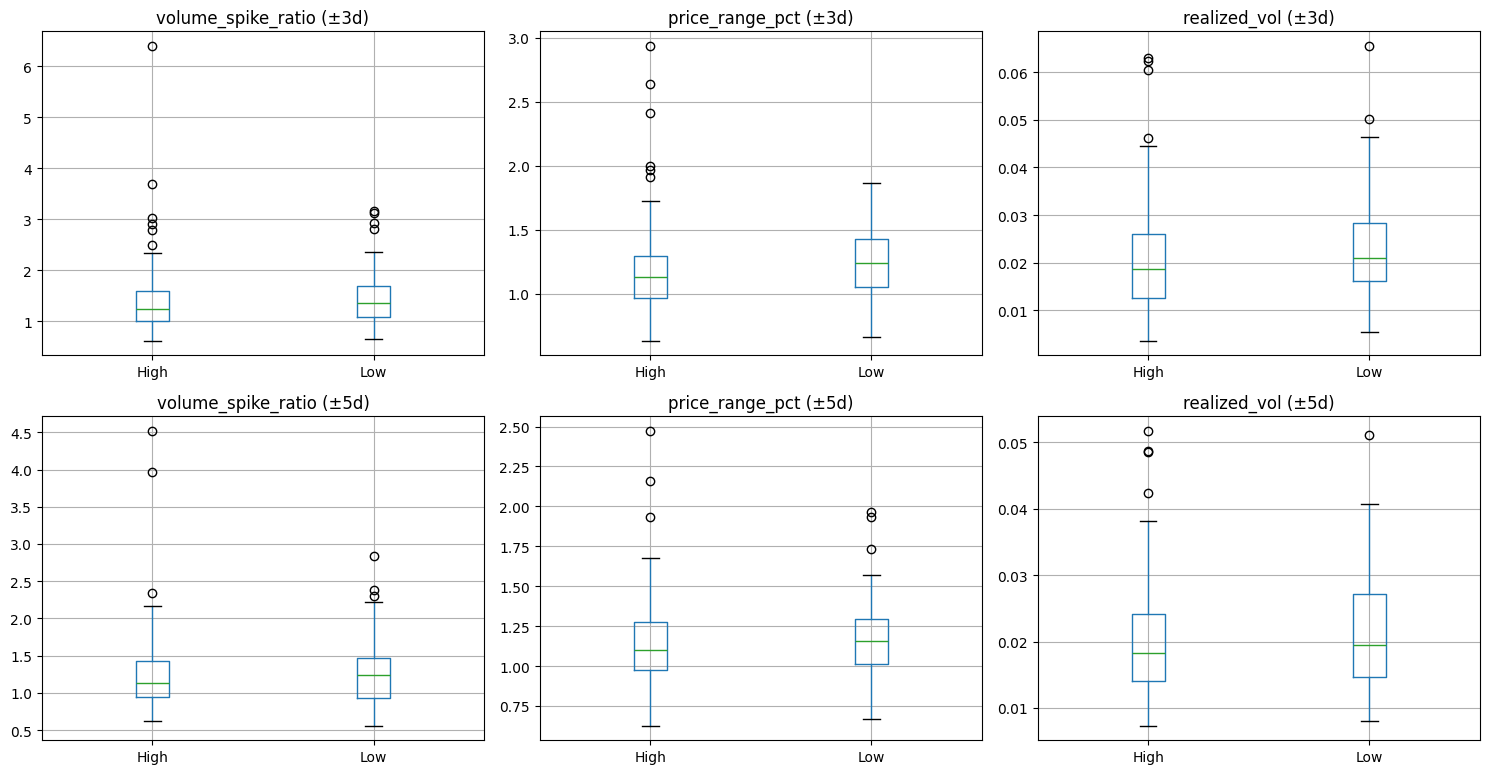

In [16]:
metric_cols = ["volume_spike_ratio", "price_range_pct", "realized_vol"]
windows = [3, 5]

fig, axes = plt.subplots(len(windows), len(metric_cols), figsize=(15, 8))

for i, window in enumerate(windows):
    sub = metrics_df[metrics_df["window_days"] == window]
    for j, metric in enumerate(metric_cols):
        ax = axes[i, j]
        sub.boxplot(column=metric, by="bucket", ax=ax)
        ax.set_title(f"{metric} (±{window}d)")
        ax.set_xlabel("")

plt.suptitle("")
plt.tight_layout()
plt.show()

No clean separation in any of the 6 panels

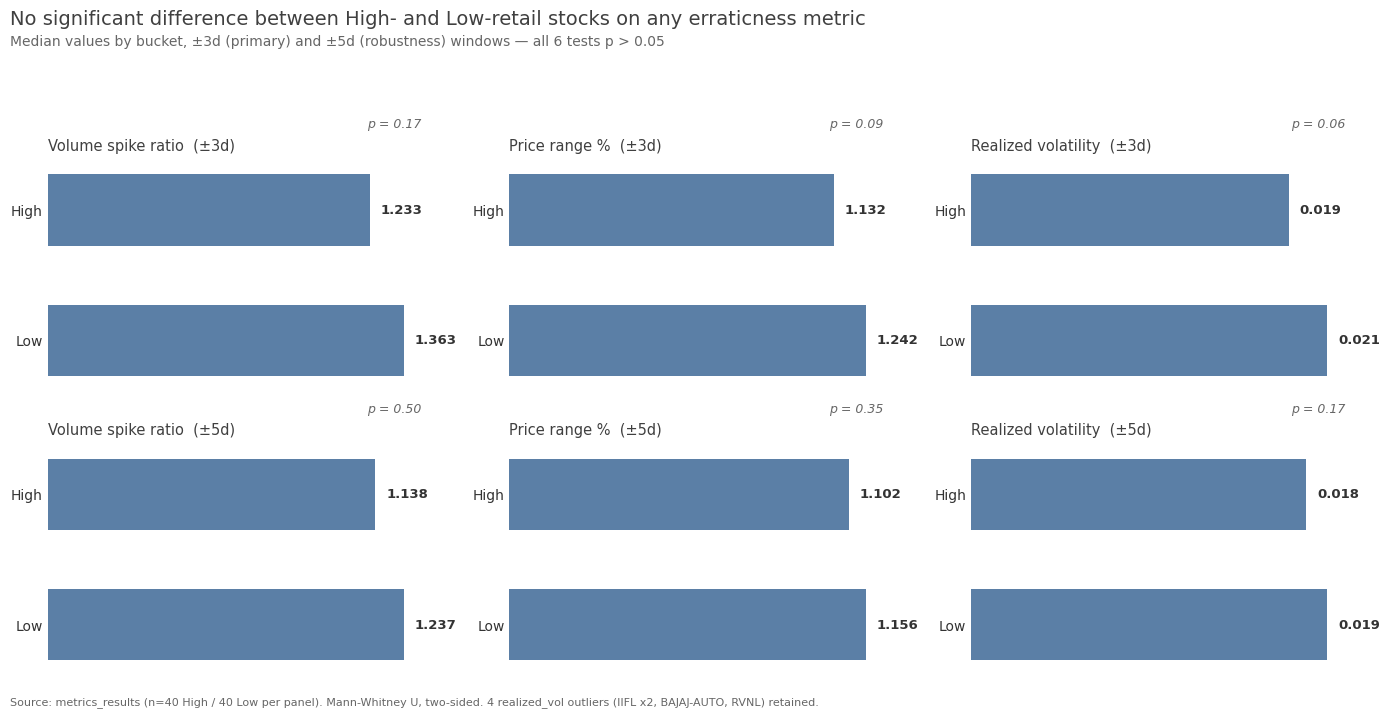

In [20]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Arial isn't installed on most Linux/Colab images -> fall back cleanly instead of warning spam
matplotlib.rcParams["font.family"] = "DejaVu Sans"

TEXT, GREY, LGREY, ACC, NEG = "#333333", "#666666", "#D9D9D9", "#1F6FB4", "#E0782F"
# darker, more readable bar color since there's no single finding to accent -
# both bars get this "readable neutral" instead of washed-out light grey
BAR = "#5B7FA6"

plt.rcParams.update({
    "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": LGREY, "xtick.color": GREY, "ytick.color": TEXT,
    "xtick.major.size": 0, "ytick.major.size": 0, "axes.grid": False,
})

metric_cols = ["volume_spike_ratio", "price_range_pct", "realized_vol"]
windows = [3, 5]
metric_labels = {
    "volume_spike_ratio": "Volume spike ratio",
    "price_range_pct": "Price range %",
    "realized_vol": "Realized volatility",
}

fig, axes = plt.subplots(len(windows), len(metric_cols), figsize=(14, 6.5))

for i, window in enumerate(windows):
    sub = metrics_df[metrics_df["window_days"] == window]
    for j, metric in enumerate(metric_cols):
        ax = axes[i, j]
        high = sub.loc[sub["bucket"] == "High", metric].dropna()
        low  = sub.loc[sub["bucket"] == "Low",  metric].dropna()
        _, p = mannwhitneyu(high, low, alternative="two-sided")

        vals = [high.median(), low.median()]
        cats = ["High", "Low"]

        bars = ax.barh(cats, vals, color=BAR, height=0.55)
        ax.invert_yaxis()
        ax.set_xticks([])
        ax.set_title(f"{metric_labels[metric]}  (±{window}d)", loc="left",
                     fontsize=10.5, color="#404040", pad=10)

        for bar, v in zip(bars, vals):
            ax.text(v + max(vals) * 0.03, bar.get_y() + bar.get_height() / 2,
                     f"{v:,.3f}", va="center", color=TEXT, fontsize=9.5, fontweight="bold")

        ax.text(1.0, 1.15, f"p = {p:.2f}", transform=ax.transAxes,
                 ha="right", va="bottom", color=GREY, fontsize=9, style="italic")

fig.suptitle("No significant difference between High- and Low-retail stocks on any erraticness metric",
             x=0.01, ha="left", fontsize=14, color="#404040", y=1.04)
fig.text(0.01, 0.985, "Median values by bucket, ±3d (primary) and ±5d (robustness) windows — all 6 tests p > 0.05",
          color=GREY, fontsize=10)
fig.text(0.01, -0.03,
          "Source: metrics_results (n=40 High / 40 Low per panel). Mann-Whitney U, two-sided. "
          "4 realized_vol outliers (IIFL x2, BAJAJ-AUTO, RVNL) retained.",
          color=GREY, fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

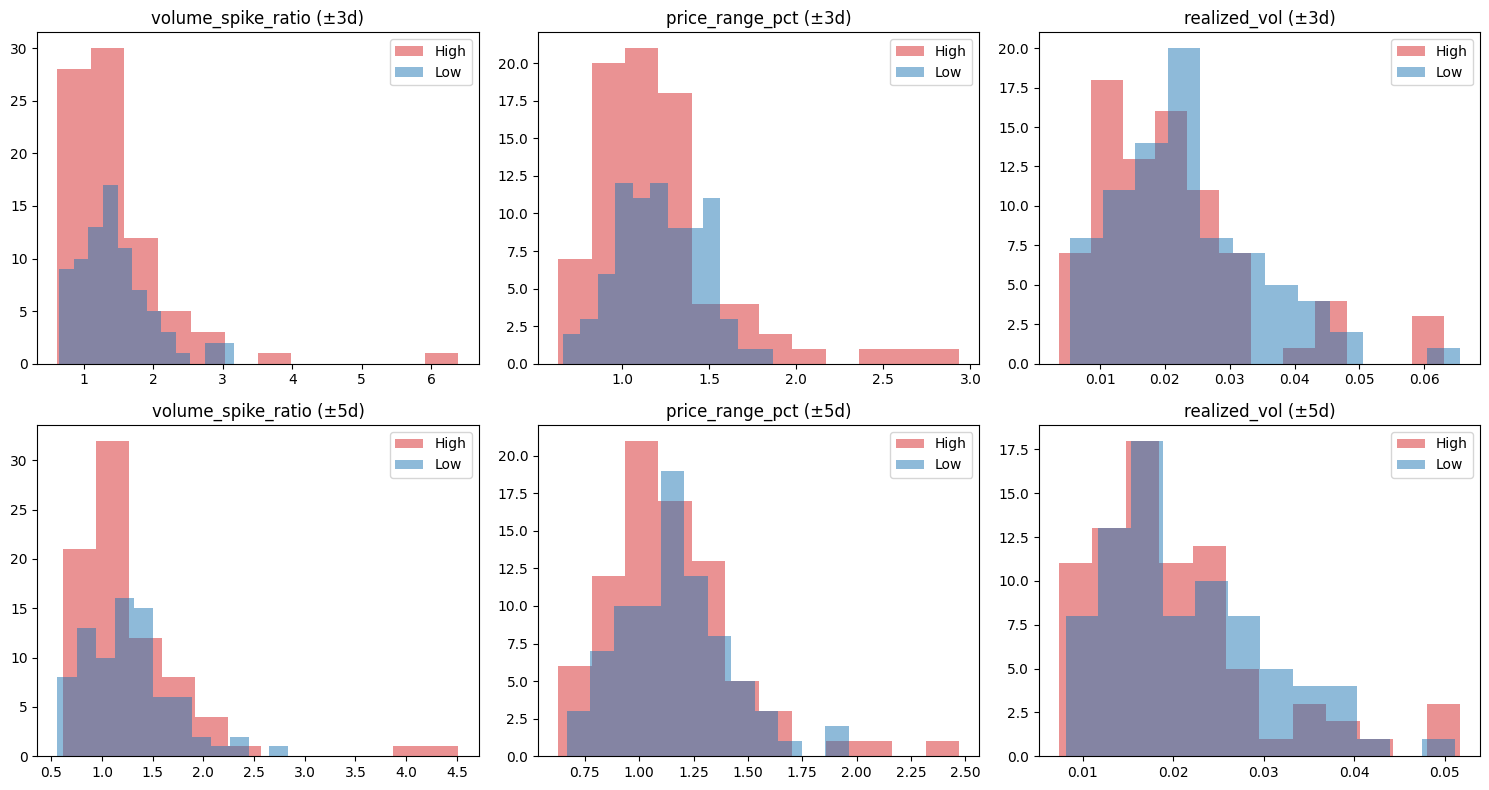

In [17]:
# Histograms, same split — gut-check for overlap vs separation
fig, axes = plt.subplots(len(windows), len(metric_cols), figsize=(15, 8))

for i, window in enumerate(windows):
    sub = metrics_df[metrics_df["window_days"] == window]
    for j, metric in enumerate(metric_cols):
        ax = axes[i, j]
        for bucket, color in [("High", "tab:red"), ("Low", "tab:blue")]:
            vals = sub.loc[sub["bucket"] == bucket, metric].dropna()
            ax.hist(vals, bins=12, alpha=0.5, label=bucket, color=color)
        ax.set_title(f"{metric} (±{window}d)")
        ax.legend()

plt.tight_layout()
plt.show()

Same conclusion as the boxplots and bar chart — heavy overlap everywhere, no separation.

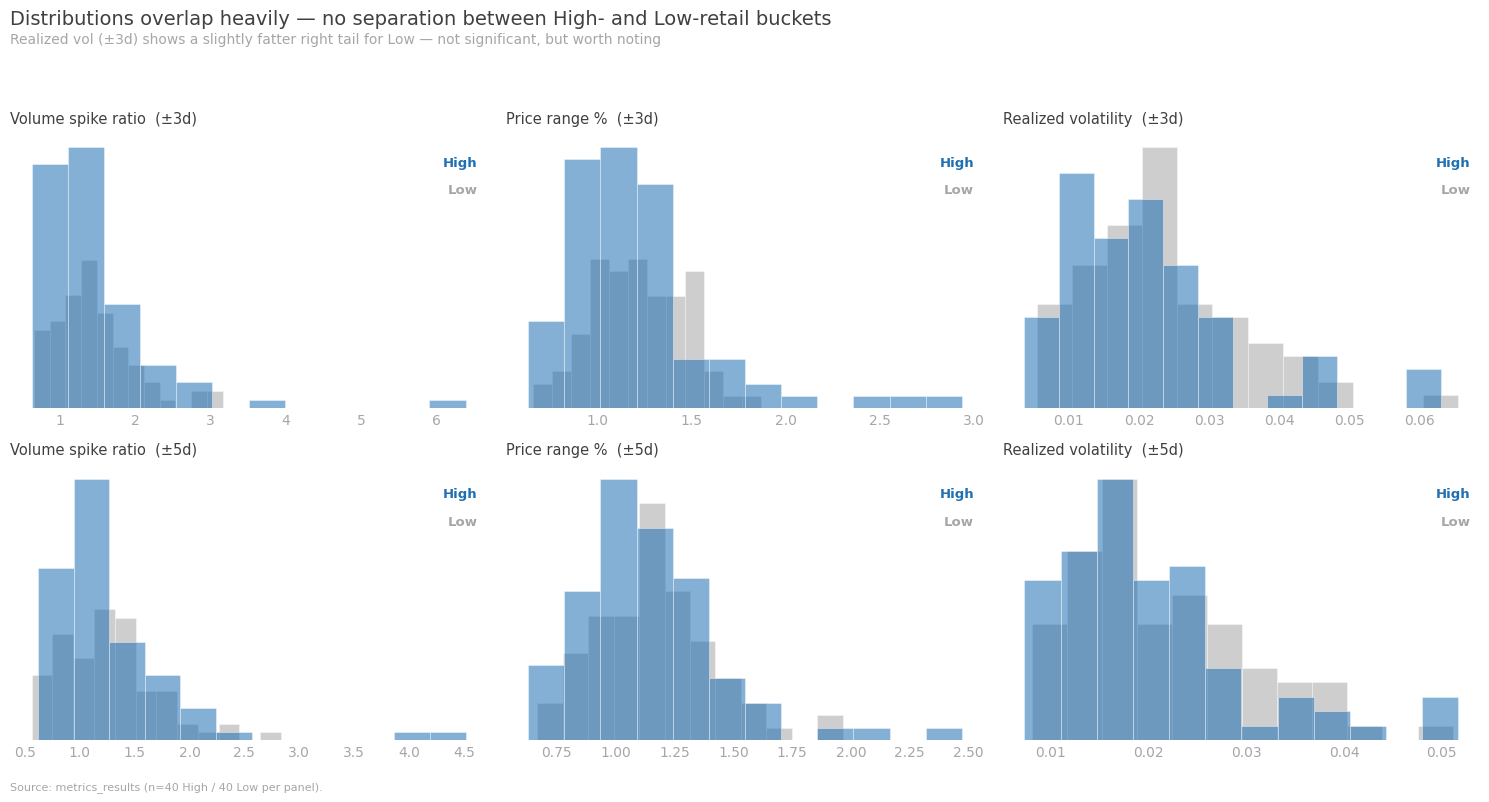

In [22]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"

TEXT, GREY, LGREY, ACC = "#333333", "#A6A6A6", "#D9D9D9", "#1F6FB4"

plt.rcParams.update({
    "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": LGREY, "xtick.color": GREY, "ytick.color": GREY,
    "xtick.major.size": 0, "ytick.major.size": 0, "axes.grid": False, "legend.frameon": False,
})

metric_cols = ["volume_spike_ratio", "price_range_pct", "realized_vol"]
windows = [3, 5]
metric_labels = {
    "volume_spike_ratio": "Volume spike ratio",
    "price_range_pct": "Price range %",
    "realized_vol": "Realized volatility",
}

fig, axes = plt.subplots(len(windows), len(metric_cols), figsize=(15, 7.5))

for i, window in enumerate(windows):
    sub = metrics_df[metrics_df["window_days"] == window]
    for j, metric in enumerate(metric_cols):
        ax = axes[i, j]
        for bucket, color, z in [("Low", GREY, 2), ("High", ACC, 3)]:
            vals = sub.loc[sub["bucket"] == bucket, metric].dropna()
            ax.hist(vals, bins=12, alpha=0.55, color=color, zorder=z, edgecolor="white", linewidth=0.5)

        ax.set_title(f"{metric_labels[metric]}  (±{window}d)", loc="left",
                     fontsize=10.5, color="#404040", pad=8)
        ax.set_yticks([])

        # direct labels instead of a legend box
        ax.text(0.98, 0.92, "High", transform=ax.transAxes, ha="right", va="top",
                 color=ACC, fontsize=9.5, fontweight="bold")
        ax.text(0.98, 0.82, "Low", transform=ax.transAxes, ha="right", va="top",
                 color=GREY, fontsize=9.5, fontweight="bold")

fig.suptitle("Distributions overlap heavily — no separation between High- and Low-retail buckets",
             x=0.01, ha="left", fontsize=14, color="#404040", y=1.02)
fig.text(0.01, 0.975,
          "Realized vol (±3d) shows a slightly fatter right tail for Low — not significant, but worth noting",
          color=GREY, fontsize=10)
fig.text(0.01, -0.02,
          "Source: metrics_results (n=40 High / 40 Low per panel).",
          color=GREY, fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 3. Mann-Whitney U — 6 tests

Mann-Whitney U, not a t-test, because retail% (and the metrics derived from it) are skewed/non-normal (Layer 1a finding) — Mann-Whitney makes no normality assumption; it compares rank-ordering between groups.

In [23]:
def run_mannwhitney(df, metric_cols, windows):
    rows = []
    for window in windows:
        sub = df[df["window_days"] == window]
        for metric in metric_cols:
            high = sub.loc[sub["bucket"] == "High", metric].dropna()
            low  = sub.loc[sub["bucket"] == "Low",  metric].dropna()

            if len(high) == 0 or len(low) == 0:
                continue

            stat, p = mannwhitneyu(high, low, alternative="two-sided")

            rows.append({
                "window_days": window,
                "metric": metric,
                "n_high": len(high),
                "n_low": len(low),
                "U_stat": stat,
                "p_value": p,
                "high_median": high.median(),
                "low_median": low.median(),
            })
    return pd.DataFrame(rows)

results_df = run_mannwhitney(metrics_df, metric_cols, windows)
results_df

,window_days,metric,n_high,n_low,U_stat,p_value,high_median,low_median
0,3,volume_spike_ratio,80,80,2802.0000,0.1749,1.2326,1.3634
1,3,price_range_pct,80,80,2701.0000,0.0889,1.1320,1.2416
2,3,realized_vol,80,80,2643.0000,0.0575,0.0188,0.0211
3,5,volume_spike_ratio,80,80,3004.0000,0.5047,1.1381,1.2371
4,5,price_range_pct,80,80,2926.0000,0.3506,1.1023,1.1556
5,5,realized_vol,80,80,2796.0000,0.1685,0.0182,0.0194


#### Interpretation — Mann-Whitney U

No metric is significant at α=0.05, but ±3d realized_vol (p=0.058) and price_range_pct (p=0.089) are close to it.

| Window | Metric | p-value | Result |
|---|---|---|---|
| ±3d | volume_spike_ratio | 0.175 | Not significant |
| ±3d | price_range_pct | 0.089 | Not significant (borderline) |
| ±3d | realized_vol | 0.058 | Not significant (borderline) |
| ±5d | volume_spike_ratio | 0.505 | Not significant |
| ±5d | price_range_pct | 0.351 | Not significant |
| ±5d | realized_vol | 0.169 | Not significant |

no proof of an effect, but a weak, consistent trend in the opposite direction of the hypothesis — strongest at ±3d.


## 4. Apply significance threshold

In [25]:
ALPHA = 0.05
N_TESTS = len(results_df)
ALPHA_BONFERRONI = ALPHA / N_TESTS

results_df["significant_at_0.05"] = results_df["p_value"] < ALPHA
results_df["significant_bonferroni"] = results_df["p_value"] < ALPHA_BONFERRONI

print(f"Plain alpha: {ALPHA} | Bonferroni-corrected alpha: {ALPHA_BONFERRONI:.4f} (over {N_TESTS} tests)")
results_df

Plain alpha: 0.05 | Bonferroni-corrected alpha: 0.0083 (over 6 tests)


,window_days,metric,n_high,n_low,U_stat,p_value,high_median,low_median,significant_at_0.05,significant_bonferroni
0,3,volume_spike_ratio,80,80,2802.0000,0.1749,1.2326,1.3634,False,False
1,3,price_range_pct,80,80,2701.0000,0.0889,1.1320,1.2416,False,False
2,3,realized_vol,80,80,2643.0000,0.0575,0.0188,0.0211,False,False
3,5,volume_spike_ratio,80,80,3004.0000,0.5047,1.1381,1.2371,False,False
4,5,price_range_pct,80,80,2926.0000,0.3506,1.1023,1.1556,False,False
5,5,realized_vol,80,80,2796.0000,0.1685,0.0182,0.0194,False,False


Nothing is significant at plain α=0.05, and Bonferroni correction (α=0.0083) is moot here — no p-value gets close to it anyway.

- **Plain α=0.05:** 0/6 tests significant.
- **Bonferroni α=0.0083:** 0/6 tests significant (would have been irrelevant even if plain α had flagged something, since the lowest p-value, 0.0575, is still ~7x the corrected threshold).

**Takeaway:** the multiple-comparison correction doesn't change the conclusion , **fail to reject H0 on all 6 tests** either way. State this plainly: **"Results hold under both uncorrected and Bonferroni-corrected thresholds — no false-positive risk from running 6 tests."**

## 5. Conclusion — ±3d primary, ±5d robustness

In [26]:
def report(results_df, window_label):
    sub = results_df[results_df["window_days"] == window_label]
    print(f"--- Window ±{window_label}d ---")
    for _, row in sub.iterrows():
        verdict = "REJECT H0 (significant)" if row["significant_at_0.05"] else "FAIL TO REJECT H0"
        bonf_note = " [also survives Bonferroni]" if row["significant_bonferroni"] else ""
        print(f"{row['metric']}: p={row['p_value']:.4f} | High median={row['high_median']:.3f} "
              f"vs Low median={row['low_median']:.3f} -> {verdict}{bonf_note}")
    print()

report(results_df, 3)
report(results_df, 5)

--- Window ±3d ---
volume_spike_ratio: p=0.1749 | High median=1.233 vs Low median=1.363 -> FAIL TO REJECT H0
price_range_pct: p=0.0889 | High median=1.132 vs Low median=1.242 -> FAIL TO REJECT H0
realized_vol: p=0.0575 | High median=0.019 vs Low median=0.021 -> FAIL TO REJECT H0

--- Window ±5d ---
volume_spike_ratio: p=0.5047 | High median=1.138 vs Low median=1.237 -> FAIL TO REJECT H0
price_range_pct: p=0.3506 | High median=1.102 vs Low median=1.156 -> FAIL TO REJECT H0
realized_vol: p=0.1685 | High median=0.018 vs Low median=0.019 -> FAIL TO REJECT H0



## Final Conclusion

No metric shows a statistically significant difference between High-retail and Low-retail stocks, and where a trend exists, it runs opposite to H1.

**Volume spike ratio:** Low-retail stocks show a higher median ratio than High-retail (Low = 1.363 vs High = 1.233, p = 0.175, Mann-Whitney U), not significant. This weakens further at ±5d (Low = 1.237 vs High = 1.138, p = 0.505), so there is no evidence here at either window — fail to reject H0.

**Price range %:** Low-retail stocks trend toward a higher median than High-retail (Low = 1.242 vs High = 1.132, p = 0.089, Mann-Whitney U), not significant but the closest of the ±3d results. This weakens at ±5d (Low = 1.156 vs High = 1.102, p = 0.351), indicating the ±3d trend is fragile and does not hold up as a robust effect — fail to reject H0.

**Realized volatility:** Low-retail stocks show marginally higher volatility than High-retail (Low = 0.021 vs High = 0.019, p = 0.058, Mann-Whitney U), the closest result to significance in the study but still not significant. This weakens at ±5d (Low = 0.019 vs High = 0.018, p = 0.169), again indicating the ±3d signal does not survive the robustness check — fail to reject H0.

**Overall:** On all three metrics and both window widths, this study fails to reject H0. There is no evidence that higher retail ownership concentration drives greater results-day erraticness in this sample — consistent with H1 being false, not with H1 being true. Where any signal exists, it is weak, strongest at ±3d, fades at ±5d, and points in the opposite direction from the hypothesis (Low-retail stocks trending marginally more erratic, not High). This is reported as the legitimate outcome of the study, not as a result to explain away.